# Credit-risk tutorial

The full workflow: mine candidate constraints from data, review and accept them, price a missing-value flip, build a rating ladder, and generate diverse alternatives.

In [1]:
import numpy as np

rng = np.random.default_rng(42)
n = 6000
names = [
    "income_monthly", "utilization", "n_active_loans", "n_loans_total",
    "max_dpd_30d", "max_dpd_12m", "months_since_last_delinq", "age",
]
income = rng.lognormal(8.3, 0.5, n).round(-1)
utilization = rng.beta(2, 3, n).round(3)
n_total = rng.poisson(4, n).astype(float) + 1
n_active = np.minimum(np.floor(n_total * rng.beta(3, 2, n)), n_total)
dpd_12m = np.floor(rng.exponential(6, n)) * (rng.random(n) < 0.4)
dpd_30d = np.floor(dpd_12m * rng.beta(2, 4, n))
months_delinq = rng.exponential(14, n).round(0)
months_delinq[dpd_12m == 0] = np.nan          # no delinquency -> no record
age = rng.integers(21, 75, n).astype(float)

X = np.column_stack([income, utilization, n_active, n_total,
                     dpd_30d, dpd_12m, months_delinq, age])
risk = (
    -0.9 * np.log(income / 4000)
    + 2.2 * utilization
    + 0.35 * dpd_30d + 0.15 * dpd_12m
    - 0.02 * np.nan_to_num(months_delinq, nan=36.0)
    - 0.015 * age
)
y = (risk + rng.logistic(scale=0.8, size=n) > np.median(risk)).astype(int)
X.shape, y.mean().round(3)

((6000, 8), np.float64(0.534))

In [2]:
import xgboost as xgb

model = xgb.XGBClassifier(n_estimators=120, max_depth=4, learning_rate=0.2,
                          random_state=0)
model.fit(X, y)
model.get_booster().feature_names = list(names)   # domain names for explanations
proba = model.predict_proba(X)[:, 1]
cutoff = 0.30                     # the credit policy's PD cutoff
applicant = X[int(np.argmax(proba))]      # a clearly declined applicant
float(model.predict_proba(applicant.reshape(1, -1))[0, 1])

0.9998112320899963

## 1. Mine candidate constraints

Invariants are mined from the sample and returned **for review** — nothing is auto-applied. Note the DPD hierarchy and loan-count order arriving as ready-to-paste code.

In [3]:
import treecf

mined = treecf.suggest_constraints(X, feature_names=names)
for s in mined[:8]:
    print(s.as_code())

constraint("n_active_loans <= n_loans_total")  # support=1.0000, n=6000
constraint("max_dpd_30d <= max_dpd_12m")  # support=1.0000, n=6000
constraint("max_dpd_12m <= income_monthly")  # support=1.0000, n=6000
constraint("months_since_last_delinq <= income_monthly")  # support=1.0000, n=2044
constraint("age <= income_monthly")  # support=1.0000, n=6000
constraint("utilization <= n_loans_total")  # support=1.0000, n=6000
constraint("n_loans_total <= age")  # support=1.0000, n=6000
constraint("max_dpd_30d <= age")  # support=1.0000, n=6000


In [4]:
accepted = [s.constraint for s in mined
            if s.kind == "order" and s.support == 1.0]
accepted

[Linear(coefficients={'n_active_loans': 1.0, 'n_loans_total': -1.0}, op='<=', rhs=0.0, missing_policy='satisfied'),
 Linear(coefficients={'max_dpd_30d': 1.0, 'max_dpd_12m': -1.0}, op='<=', rhs=0.0, missing_policy='satisfied'),
 Linear(coefficients={'max_dpd_12m': 1.0, 'income_monthly': -1.0}, op='<=', rhs=0.0, missing_policy='satisfied'),
 Linear(coefficients={'months_since_last_delinq': 1.0, 'income_monthly': -1.0}, op='<=', rhs=0.0, missing_policy='satisfied'),
 Linear(coefficients={'age': 1.0, 'income_monthly': -1.0}, op='<=', rhs=0.0, missing_policy='satisfied'),
 Linear(coefficients={'utilization': 1.0, 'n_loans_total': -1.0}, op='<=', rhs=0.0, missing_policy='satisfied'),
 Linear(coefficients={'n_loans_total': 1.0, 'age': -1.0}, op='<=', rhs=0.0, missing_policy='satisfied'),
 Linear(coefficients={'max_dpd_30d': 1.0, 'age': -1.0}, op='<=', rhs=0.0, missing_policy='satisfied')]

## 2. Explain with a priced missing-value flip

`months_since_last_delinq` is NaN when there is no delinquency record — and *reaching* that state is a legitimate recommendation with an explicit price (`delta_miss`).

In [5]:
from treecf import AllowMissing, Explainer, Freeze, Target

exp = Explainer(
    model,
    background=X,
    constraints=accepted + [
        Freeze("age"),
        AllowMissing("months_since_last_delinq", delta_miss=2.0),
    ],
    value_policy={"max_dpd_30d": "integer", "max_dpd_12m": "integer",
                  "n_active_loans": "integer", "n_loans_total": "integer"},
)
res = exp.explain(applicant, target=Target.probability(range=(0.0, cutoff)))
res.changes

{'income_monthly': (5550.0, 5519.999999),
 'utilization': (0.727, 0.187999),
 'max_dpd_30d': (12.0, 0.0),
 'max_dpd_12m': (19.0, 7.0),
 'months_since_last_delinq': (9.0, nan)}

## 3. The rating ladder

One compilation, one solve per band: the increasing cost of each better grade.

In [6]:
ladder = exp.explain(applicant, target=Target.bands({
    "approve": (0.00, 0.30),
    "prime":   (0.00, 0.15),
    "super":   (0.00, 0.05),
}))
{k: (round(v.distance, 3) if hasattr(v, 'distance') else v.reason)
 for k, v in ladder.items()}

{'approve': 15.436, 'prime': 17.454, 'super': 18.474}

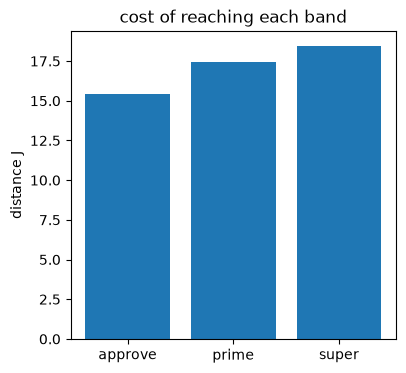

In [7]:
from treecf.viz import plot_ladder

plot_ladder(ladder);

## 4. Diverse alternatives

No-good cuts produce structurally different recommendations, in non-decreasing cost order.

In [8]:
diverse = exp.explain(applicant,
                      target=Target.probability(range=(0.0, cutoff)),
                      n_counterfactuals=3)
[sorted(r.changes) for r in diverse]

[['income_monthly', 'max_dpd_12m', 'max_dpd_30d', 'months_since_last_delinq'],
 ['income_monthly',
  'max_dpd_12m',
  'max_dpd_30d',
  'months_since_last_delinq',
  'n_active_loans',
  'utilization'],
 ['income_monthly',
  'max_dpd_12m',
  'max_dpd_30d',
  'months_since_last_delinq',
  'utilization']]

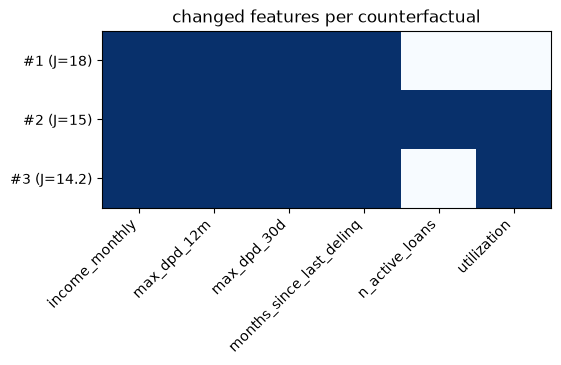

In [9]:
from treecf.viz import plot_counterfactuals

plot_counterfactuals(diverse);